In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [2]:
df=pd.read_csv('/content/consumer_insights.csv')

In [3]:
df.sample(5)

,user_id,persona,trend_affinity,age_group,gender_identity,income_bracket,dietary_restriction
3461,U03462,fitness,clean-label,25-34,Woman,Medium,NaN
370,U00371,NaN,protein,35-44,Man,High,NaN
3150,U03151,budget,protein,35-44,Woman,Medium,NaN
939,U00940,premium,gut-health,25-34,Non-binary,Medium,NaN
458,U00459,budget,low-sugar,45-54,Man,Medium,Halal


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_id              5000 non-null   object
 1   persona              4724 non-null   object
 2   trend_affinity       5000 non-null   object
 3   age_group            5000 non-null   object
 4   gender_identity      5000 non-null   object
 5   income_bracket       5000 non-null   object
 6   dietary_restriction  2075 non-null   object
dtypes: object(7)
memory usage: 273.6+ KB


In [10]:
col=['persona','trend_affinity','gender_identity','dietary_restriction']
for i in col:
  print(df[i].value_counts())
  print('##############')

persona
fitness    1201
casual     1189
budget     1169
premium    1165
Name: count, dtype: int64
##############
trend_affinity
plant-based    1035
clean-label    1004
protein         994
gut-health      990
low-sugar       977
Name: count, dtype: int64
##############
gender_identity
Man                  2257
Woman                2256
Non-binary            372
Prefer not to say     115
Name: count, dtype: int64
##############
dietary_restriction
Vegetarian     551
Vegan          498
Pescatarian    264
Kosher         256
Halal          256
Jain           250
Name: count, dtype: int64
##############


In [12]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [13]:
df[df['persona'].isnull()].sample(20)

,user_id,persona,trend_affinity,age_group,gender_identity,income_bracket,dietary_restriction
3880,U03881,NaN,protein,45-54,Man,Medium,Pescatarian
3082,U03083,NaN,protein,18-24,Woman,Low,Vegetarian
3135,U03136,NaN,protein,25-34,Man,High,NaN
1088,U01089,NaN,gut-health,25-34,Woman,Low,NaN
4473,U04474,NaN,plant-based,55+,Woman,Medium,Kosher
4477,U04478,NaN,gut-health,25-34,Man,Medium,Vegetarian
4388,U04389,NaN,low-sugar,45-54,Woman,Medium,Vegetarian
2254,U02255,NaN,plant-based,55+,Woman,High,Vegetarian
1483,U01484,NaN,clean-label,25-34,Man,Medium,NaN
4861,U04862,NaN,low-sugar,45-54,Woman,Medium,NaN


In [14]:
pd.crosstab(df['persona'], df['trend_affinity'])

trend_affinity,clean-label,gut-health,low-sugar,plant-based,protein
persona,,,,,
budget,225,230,234,250,230
casual,263,240,240,224,222
fitness,233,229,245,267,227
premium,236,238,206,237,248


In [15]:
pd.crosstab(df['persona'], df['dietary_restriction'])

dietary_restriction,Halal,Jain,Kosher,Pescatarian,Vegan,Vegetarian
persona,,,,,,
budget,54,67,60,54,125,113
casual,57,62,58,74,119,122
fitness,54,57,60,60,115,145
premium,74,58,59,58,114,137


In [16]:
pd.crosstab(df['persona'], df['income_bracket'])

income_bracket,High,Low,Medium
persona,,,
budget,271,301,597
casual,236,356,597
fitness,235,360,606
premium,230,374,561


##As wee did not find relation persona with categorical column

In [17]:
mask = df['persona'].isna()
df.loc[mask, 'persona'] = np.random.choice(
    ['fitness', 'casual', 'budget', 'premium'],
    size=mask.sum()
)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_id              5000 non-null   object
 1   persona              5000 non-null   object
 2   trend_affinity       5000 non-null   object
 3   age_group            5000 non-null   object
 4   gender_identity      5000 non-null   object
 5   income_bracket       5000 non-null   object
 6   dietary_restriction  2075 non-null   object
dtypes: object(7)
memory usage: 273.6+ KB


In [19]:
df['dietary_restriction'].value_counts()

,count
dietary_restriction,
Vegetarian,551
Vegan,498
Pescatarian,264
Kosher,256
Halal,256
Jain,250


In [20]:
df['dietary_restriction'].fillna('N/A',inplace=True)

/tmp/ipykernel_3788/954679702.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['dietary_restriction'].fillna('N/A',inplace=True)


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_id              5000 non-null   object
 1   persona              5000 non-null   object
 2   trend_affinity       5000 non-null   object
 3   age_group            5000 non-null   object
 4   gender_identity      5000 non-null   object
 5   income_bracket       5000 non-null   object
 6   dietary_restriction  5000 non-null   object
dtypes: object(7)
memory usage: 273.6+ KB


In [22]:
df['age_group'].value_counts()

,count
age_group,
25-34,1724
18-24,1271
35-44,1007
45-54,605
55+,393


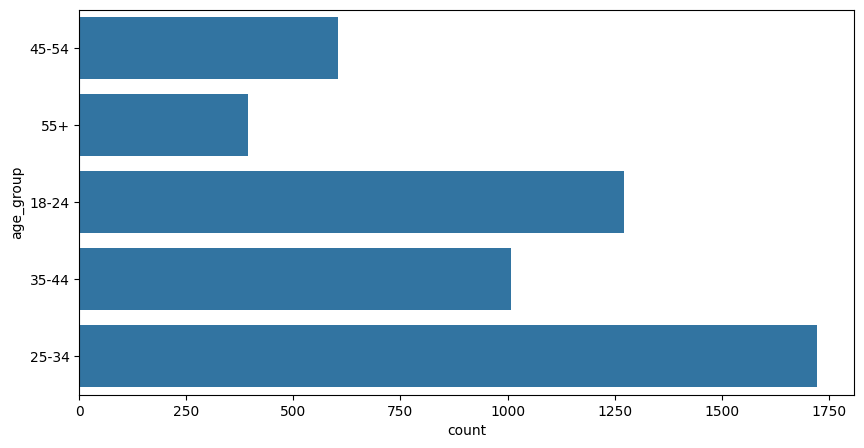

In [24]:
plt.figure(figsize=(10,5))
sns.countplot(df['age_group'])
plt.show()

In [25]:
from google.colab import files
df.to_csv('consumer_insights1.csv', index=False)
files.download('consumer_insights1.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>